Training Concept Bottleneck Model...
Epoch 020/120 | Loss: 1.8102 (Concept: 0.5152, Label: 1.2950)
Epoch 040/120 | Loss: 1.4244 (Concept: 0.4088, Label: 1.0156)
Epoch 060/120 | Loss: 0.9598 (Concept: 0.3453, Label: 0.6145)
Epoch 080/120 | Loss: 0.6276 (Concept: 0.3029, Label: 0.3247)
Epoch 100/120 | Loss: 0.4496 (Concept: 0.2648, Label: 0.1847)
Epoch 120/120 | Loss: 0.3525 (Concept: 0.2267, Label: 0.1258)

MODEL PERFORMANCE ON DOWNSTREAM CLASSES
Concept Bottleneck Accuracy: 100.00%

Explaining Decision for Text: 'The rocket launched into orbit around mars'
--------------------------------------------------
Predicted Concept Activation Scores:
 - space     : 11.3%
 - orbit     : 10.4%
 - graphics  : 6.5%
 - image     : 12.6%
 - god       : 11.9%
 - faith     : 6.8%
 - science   : 91.8%
 - physics   : 89.9%
Final Decision Reached: Science


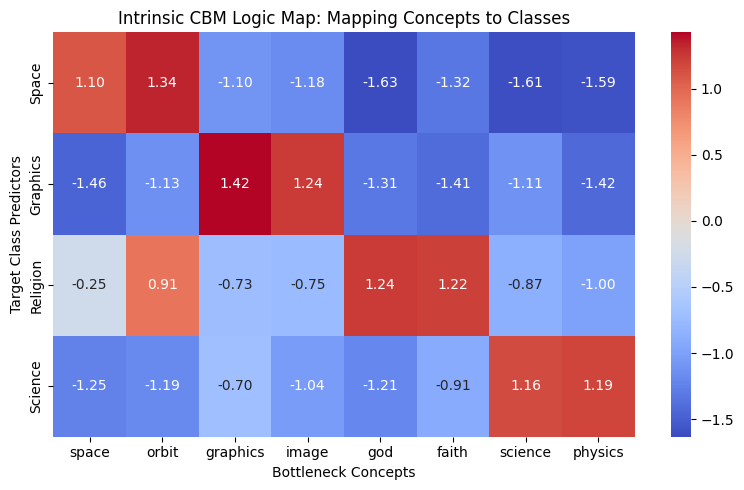

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # hide warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.optim as optim  # weight optimizers
from sklearn.feature_extraction.text import TfidfVectorizer  # text vectorizer
from sklearn.model_selection import train_test_split  # data splitter
from sklearn.metrics import accuracy_score, classification_report  # evaluation metrics
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # styling charts

warnings.filterwarnings('ignore')  # silence warnings

SEED = 42  # standard seed
np.random.seed(SEED)  # seed numpy
torch.manual_seed(SEED)  # seed pytorch

# ==========================================
# Get / Generate Datasets
# ==========================================

# Simple text dataset matching 4 categories (Space, Graphics, Religion, Science)
texts = [
    "The rocket launched into orbit around mars", "nasa space exploration program satellite",
    "rendering graphics card 3d design texture", "photoshop computer image digital pixel",
    "atheism arguments against theological claims", "faith god church bible spiritual belief",
    "computational algorithm writing software code", "science quantum physics research laboratory"
] * 25  # expand dataset samples

labels = [0, 0, 1, 1, 2, 2, 3, 3] * 25  # target classes (0: Space, 1: Graphics, 2: Religion, 3: Science)

# Convert raw text into numerical tf-idf features
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')  # init tf-idf
X = vectorizer.fit_transform(texts).toarray()  # compute tf-idf array

# Define human-readable concepts to build the bottleneck layer
concept_words = ['space', 'orbit', 'graphics', 'image', 'god', 'faith', 'science', 'physics']
concepts = np.zeros((len(texts), len(concept_words)))  # init concepts matrix

# Automatically generate ground-truth concept labels by word occurrences
for i, t in enumerate(texts):
    for c_idx, word in enumerate(concept_words):
        if word in t.lower():
            concepts[i, c_idx] = 1.0  # flag concept present

# Split dataset into train and test sets
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    X, labels, concepts, test_size=0.20, random_state=SEED
)

# Convert all datasets to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)
c_train_t = torch.FloatTensor(c_train)
c_test_t = torch.FloatTensor(c_test)

# ==========================================
# Concept Bottleneck Model Architecture
# ==========================================

class ConceptBottleneckModel(nn.Module):
    def __init__(self, vocab_size, num_concepts, num_classes):
        super().__init__()
        # Step 1: map input words directly to binary concepts
        self.concept_extractor = nn.Linear(vocab_size, num_concepts, bias=False)
        # Step 2: predict class strictly from those concepts
        self.label_predictor = nn.Linear(num_concepts, num_classes)

    def forward(self, x):
        c_pred = torch.sigmoid(self.concept_extractor(x))  # predict concept probabilities
        y_pred = self.label_predictor(c_pred)  # predict final classes
        return y_pred, c_pred  # return both layers

# Initialize model using dynamic input vocabulary sizes
vocab_size = X.shape[1]
model = ConceptBottleneckModel(vocab_size, len(concept_words), 4)

# Setup losses & optimization
criterion_c = nn.BCELoss()  # binary loss for concepts bottleneck
criterion_y = nn.CrossEntropyLoss()  # multi-class loss for labels
optimizer = optim.Adam(model.parameters(), lr=0.01)  # model parameters optimizer

# ==========================================
# Train Network
# ==========================================

print("Training Concept Bottleneck Model...")  # status log
for epoch in range(120):  # training epochs
    model.train()  # set training state

    y_pred_t, c_pred_t = model(X_train_t)  # forward pass

    loss_c = criterion_c(c_pred_t, c_train_t)  # calculate concepts bottleneck loss
    loss_y = criterion_y(y_pred_t, y_train_t)  # calculate classes output loss
    loss = loss_c + loss_y  # fuse losses

    optimizer.zero_grad()  # clean variables
    loss.backward()  # backpropagation
    optimizer.step()  # update weights

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}/120 | Loss: {loss.item():.4f} (Concept: {loss_c.item():.4f}, Label: {loss_y.item():.4f})")

# ==========================================
# Evaluation & Inference Interpretation
# ==========================================

model.eval()  # set evaluation state
with torch.no_grad():  # freeze gradients
    y_test_pred, c_test_pred = model(X_test_t)  # predict test sets
    test_acc = accuracy_score(y_test, torch.argmax(y_test_pred, dim=1).numpy())  # score labels accuracy

print("\n=====================================")
print("MODEL PERFORMANCE ON DOWNSTREAM CLASSES")
print("=====================================")
print(f"Concept Bottleneck Accuracy: {test_acc * 100:.2f}%")
print("=====================================")

# Decode predicted concepts for a single, target test sample to demonstrate logic
sample_idx = 0  # inspect first test sample
sample_text = texts[train_idx := len(X_train) + sample_idx]  # get raw text
sample_concepts = c_test_pred[sample_idx].numpy()  # get predicted concept probabilities
predicted_class = torch.argmax(y_test_pred[sample_idx]).item()  # get predicted label class

class_labels = {0: 'Space', 1: 'Graphics', 2: 'Religion', 3: 'Science'}  # dictionary labels

print(f"\nExplaining Decision for Text: '{sample_text}'")
print("-" * 50)
print("Predicted Concept Activation Scores:")
for i, name in enumerate(concept_words):
    print(f" - {name:10s}: {sample_concepts[i] * 100:.1f}%")  # display active concepts
print(f"Final Decision Reached: {class_labels[predicted_class]}")

# ==========================================
# Visualize Model's Decision Logic
# ==========================================

# Plot the linear weights mapping predicted concepts directly to final classes
weights = model.label_predictor.weight.detach().numpy()  # pull weight arrays

plt.figure(figsize=(8, 5))  # canvas size
sns.heatmap(weights, annot=True, cmap="coolwarm", xticklabels=concept_words, yticklabels=class_labels.values(), fmt=".2f", cbar=True)  # draw mapping heatmap
plt.xlabel("Bottleneck Concepts")  # x label
plt.ylabel("Target Class Predictors")  # y label
plt.title("Intrinsic CBM Logic Map: Mapping Concepts to Classes")  # plot title
plt.tight_layout()  # fit layouts
plt.show()  # render plot